In [99]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats.mstats import winsorize
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Locate repository root and estimation directory
current = Path.cwd().resolve()
repo_root = next((p for p in [current, *current.parents] if (p / 'Empirical').exists() and (p / 'Theory').exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not locate repository root containing 'Empirical' and 'Theory'.")

estimation_dir = repo_root / 'Empirical' / 'estimation'
if str(estimation_dir) not in sys.path:
    sys.path.insert(0, str(estimation_dir))
os.chdir(estimation_dir)

import stage1 as stage1_module
stage1_module.sm = sm

from stage1 import to_ar1_innovations
from grid_search import estimate_single_config

In [100]:
# Structural parameters (same calibration used in theory notebooks)
a = 1.55
gamma = 2.0
sigma = 0.001
delta = 0.9
phi = np.exp(sigma**2 / 2)
kappa = delta * a ** (-gamma) * phi
w = -np.log(kappa) - np.exp(-10)

window_size = 100
n_lags = 1
correct_with_tanh = True
standardize_features = False

print(f'kappa={kappa:.6f}, w={w:.6f}, window={window_size}, standardize={standardize_features}')

kappa=0.374610, w=0.981824, window=100, standardize=False


In [101]:
# Build topic innovations (X candidate)
topics = pd.read_csv(repo_root / 'Empirical' / 'data' / 'merged_return_topic_data.csv')
topics = topics[[col for col in topics.columns if not any(char.isdigit() for char in col)]]
topics.set_index('date', inplace=True)
topics = to_ar1_innovations(topics)
topics = topics.iloc[1:]
topics = topics.apply(lambda col: winsorize(col, limits=[0.01, 0.01]))
topics = topics.astype(float)
topics = topics.dropna(axis=0, how='any')

# Standardize topics once, then use the same standardized X in simulation and estimation
if standardize_features:
    scaler_topics = StandardScaler()
    topics = pd.DataFrame(
        scaler_topics.fit_transform(topics),
        index=topics.index,
        columns=topics.columns
    )

print(f'Topic innovation matrix shape: {topics.shape}')
print(f'Average variance after preprocessing: {float(topics.var().mean()):.6f}')

Topic innovation matrix shape: (1888, 180)
Average variance after preprocessing: 0.000008


In [102]:
# Lambda calibration: back out lambda from the theoretical stationary distribution of beta.
# For rolling-window OLS with window W, the theory gives:
#   sd_beta = sigma_d * sqrt((1-kappa)/2) / (sigma_x * sqrt(W))
# We set lambda such that a null topic is selected with probability target_selection_prob.
from scipy.stats import norm

target_selection_prob = 0.02

L = window_size
sigma_x_var_avg = float(topics.var().mean())
sigma_x_for_formula = np.sqrt(sigma_x_var_avg)
sigma_d = sigma

sd_beta = sigma_d * np.sqrt((1.0 - kappa) / 2.0) / (sigma_x_for_formula * np.sqrt(L))
z_crit = norm.ppf(1 - target_selection_prob / 2)
lambda_beta_target = z_crit * sd_beta

d_avg = float((topics.to_numpy() ** 2).mean())
lambda_val = float(lambda_beta_target * d_avg) 

print(f'target_selection_prob = {target_selection_prob}')
print(f'sd_beta               = {sd_beta:.3e}')
print(f'z_crit                = {z_crit:.3f}')
print(f'lambda_beta_target    = {lambda_beta_target:.3e}')
print(f'd_avg                 = {d_avg:.6f}')
print(f'lambda_val (sklearn)  = {lambda_val:.3e}')

target_selection_prob = 0.02
sd_beta               = 1.945e-02
z_crit                = 2.326
lambda_beta_target    = 4.525e-02
d_avg                 = 0.000008
lambda_val (sklearn)  = 3.738e-07


In [110]:
def multivariate_CGL_offline_lasso_with_X(X, sigma, kappa, w, rolling_window_size=300, lambda_lasso=1e-5, correct_with_tanh=False, random_seed=12345):
    """
    Same recursion as Theory/simulate_Lasso.ipynb multivariate_CGL_offline_lasso,
    but takes X as input instead of simulating X internally.
    """
    X = np.asarray(X, dtype=float)
    T, K = X.shape
    assert rolling_window_size < T, 'rolling_window_size must be less than T'

    rng = np.random.default_rng(random_seed)
    beta_offline = np.zeros((T, K, 1))
    r_offline = np.zeros(T)

    r_offline[1:rolling_window_size + 1] = rng.normal(0, 1e-4, rolling_window_size)

    for t in range(rolling_window_size + 1, T):
        x_current = X[t - rolling_window_size - 1 : t - 1, :]
        r_offline_current = r_offline[t - rolling_window_size : t]

        beta_offline[t, :, 0] = Lasso(
            alpha=lambda_lasso, fit_intercept=False, random_state=42
        ).fit(x_current, r_offline_current).coef_

        pred_tm1 = float(beta_offline[t - 1, :, 0] @ X[t - 1, :])
        pred_t = float(beta_offline[t, :, 0] @ X[t, :])

        if correct_with_tanh:
            r_offline[t] = (
                np.log(1 - kappa * np.exp(w * np.tanh(pred_tm1 / w)))
                - np.log(1 - kappa * np.exp(w * np.tanh(pred_t / w)))
                + rng.normal(0, sigma)
            )
        else:
            r_offline[t] = (
                np.log(1 - kappa * np.exp(pred_tm1))
                - np.log(1 - kappa * np.exp(pred_t))
                + rng.normal(0, sigma)
            )

    return beta_offline, r_offline, X

In [126]:
def run_oracle_test(X_df, label, random_seed):
    X = X_df.to_numpy()

    beta_true, y_sim, X_used = multivariate_CGL_offline_lasso_with_X(
        X=X,
        sigma=sigma,
        kappa=kappa,
        w=w,
        rolling_window_size=window_size,
        lambda_lasso=lambda_val,
        correct_with_tanh=correct_with_tanh,
        random_seed = random_seed
    )

    est = estimate_single_config(
        X=X_used,
        y=y_sim,
        window_size=window_size,
        n_lags=n_lags,
        lambda_val=lambda_val,
        standardize=standardize_features,
        verbose=False,
        save_only_positve_r_squared=False,
        return_details=True
    )

    summary = est.get('summary', {})
    details = est['details']
    beta_cols = [c for c in details.columns if c.startswith('Lasso_')]
    beta_est = details[beta_cols].to_numpy()

    beta_true_2d = beta_true[:, :, 0]
    common_t = min(beta_est.shape[0], beta_true_2d.shape[0])
    beta_est_aligned = beta_est[-common_t:, :]
    beta_true_aligned = beta_true_2d[-common_t:, :]

    beta_rmse = float(np.sqrt(np.nanmean((beta_est_aligned - beta_true_aligned) ** 2)))

    n_active_value = np.sum(beta_est != 0)


    out = {
        'label': label,
        'n_obs': int(X_used.shape[0]),
        'n_topics': int(X_used.shape[1]),
        'true_kappa': float(kappa),
        'estimated_kappa': float(summary.get('kappa', np.nan)),
        'kappa_abs_error': float(abs(summary.get('kappa', np.nan) - kappa)) if not np.isnan(summary.get('kappa', np.nan)) else np.nan,
        'kappa_tstat': float(summary.get('kappa_tstat', np.nan)),
        'stage1_r2_oos': float(summary.get('r2_oos_stage1', np.nan)),
        'stage2_r2_oos': float(summary.get('r2_oos_stage2', np.nan)),
        'stage1_r2_insample': float(summary.get('r2_insample_stage1', np.nan)),
        'stage2_r2_insample': float(summary.get('r2_insample_stage2', np.nan)),
        'beta_rmse': beta_rmse,
        'n_active_stage1': float(n_active_value) if not np.isnan(n_active_value) else np.nan
    }

    return out, details, beta_true

In [132]:
all_summaries = []
all_details = []
all_beta_trues = []

print("Starting oracle tests for 100 random seeds...")

# Changed to 100 as per your previous request; use range(10) if you just want a quick test
for seed in range(500):
    # Unpack the three return values from your function
    summary_dict, details_df, b_true = run_oracle_test(topics, label='estimation_', random_seed=seed)
    
    # Add seed to the summary for tracking
    summary_dict['seed'] = seed
    
    all_summaries.append(summary_dict)
    all_details.append(details_df)
    all_beta_trues.append(b_true)

# 1. results becomes a DataFrame of the metrics
results_df = pd.DataFrame(all_summaries)

# 2. details and beta_true remain lists (since they contain DataFrames/Arrays for each seed)
# You can access a specific one via details[0] or beta_true[0]
details_list = all_details
beta_true_list = all_beta_trues

print("Tests complete.")
print(f"Metrics shape: {results_df.shape}")

Starting oracle tests for 100 random seeds...
Tests complete.
Metrics shape: (500, 14)


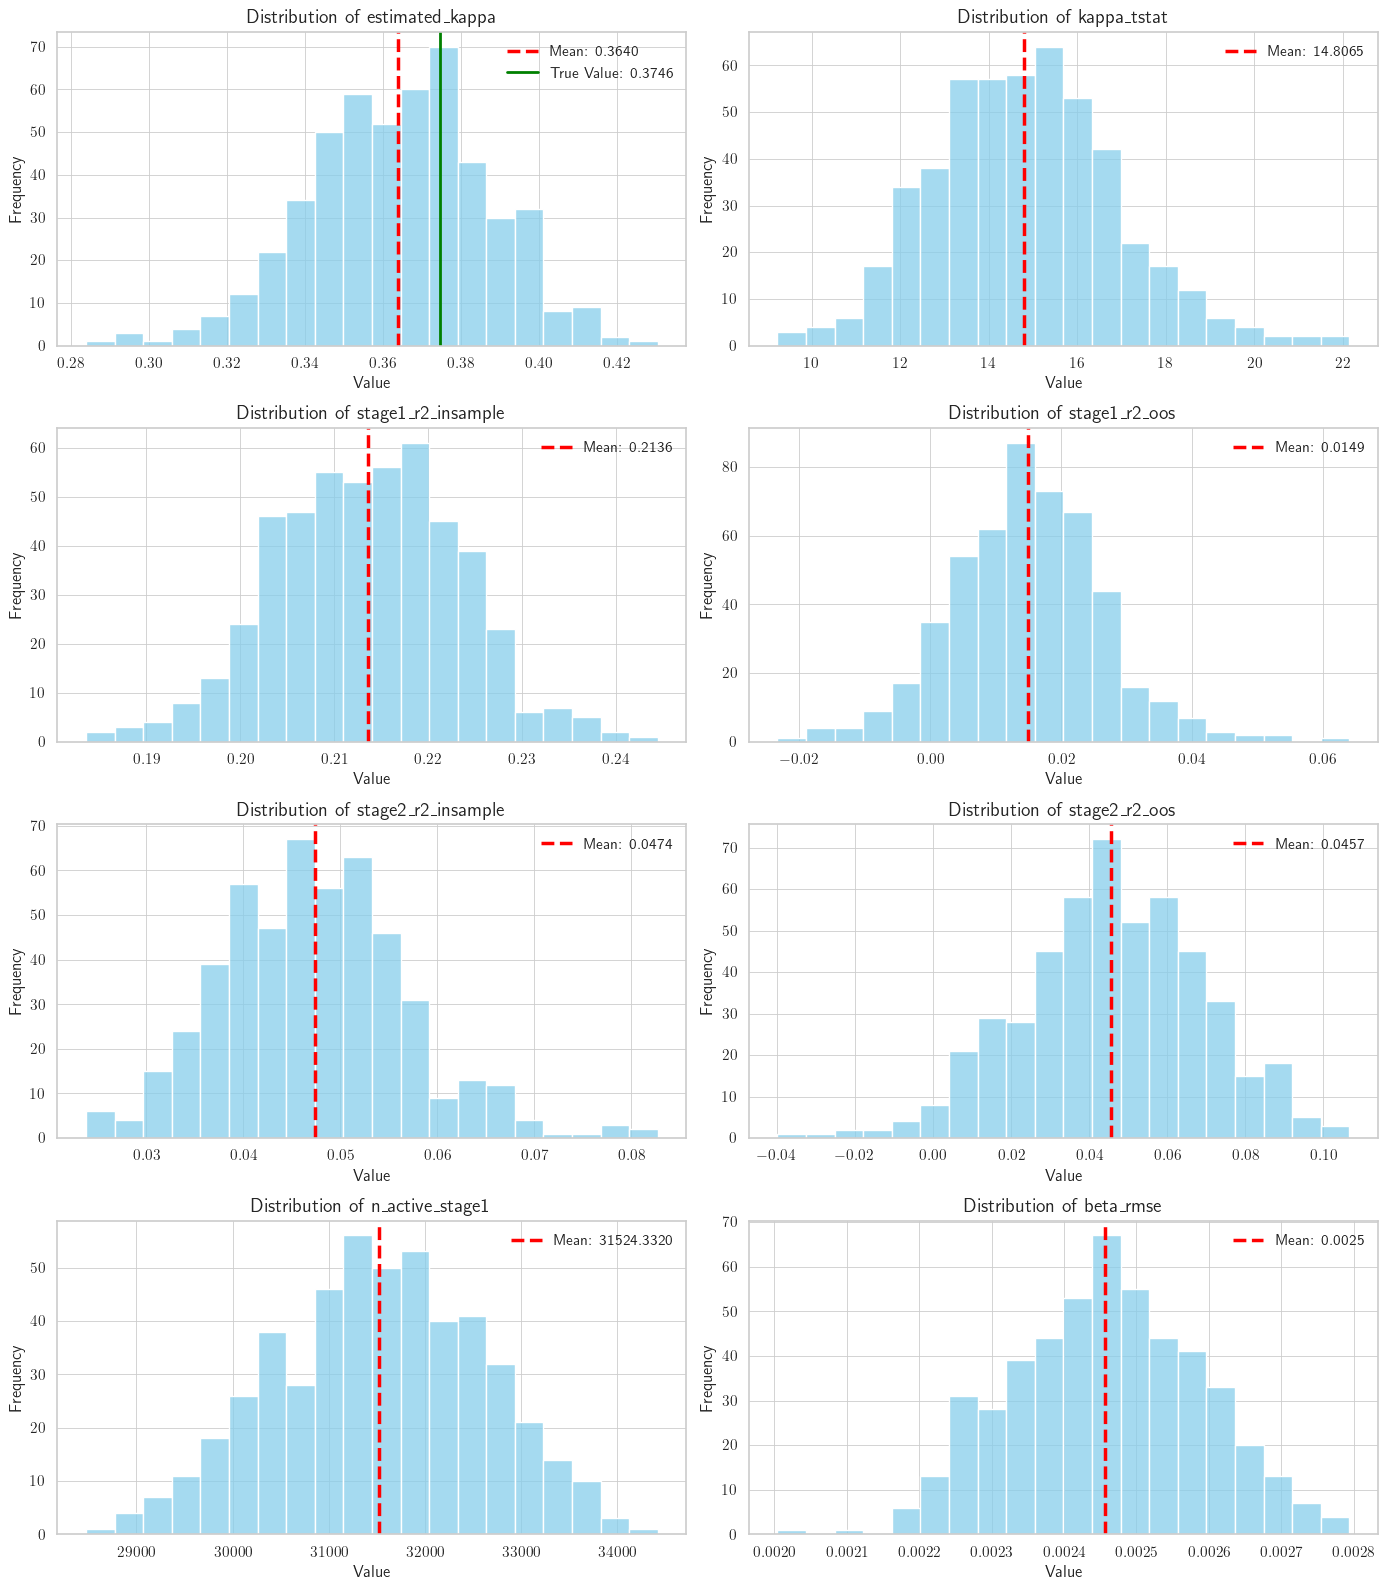

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the columns we want to visualize
# We skip constants like n_obs, n_topics, and true_kappa
metrics_to_plot = [
    'estimated_kappa', 'kappa_tstat', 
    'stage1_r2_insample', 'stage1_r2_oos',
    'stage2_r2_insample', 'stage2_r2_oos',
    'n_active_stage1', 'beta_rmse'
]

# 2. Set up the figure grid (e.g., 4 rows by 2 columns)
n_cols = 2
n_rows = int(np.ceil(len(metrics_to_plot) / n_cols))

plt.figure(figsize=(14, 4 * n_rows))
sns.set_style("whitegrid")

for i, col in enumerate(metrics_to_plot):
    if col not in results_df.columns:
        continue
        
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    # Plot histogram with Kernel Density Estimate (KDE)
    sns.histplot(results_df[col], kde=False, color="skyblue", bins=20)
    
    # Add a vertical line for the mean
    mean_val = results_df[col].mean()
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')
    
    # Special Case: Highlight the True Kappa if plotting estimated_kappa
    if col == 'estimated_kappa' and 'true_kappa' in results_df.columns:
        true_k = results_df['true_kappa'].iloc[0]
        plt.axvline(true_k, color='green', linestyle='-', linewidth=2, label=f'True Value: {true_k:.4f}')
    
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()